# Machine Learning - Practical 3 - Multiclass Logistic Regression, MLP and CNNs


Names: {Lafi Selma , Jakob Kauws}  
Summer Term 2026

**Please note that this practical requires training a lot of models, which may be time consuming (~2h)**

In this practical we will implement multiclass classification with classic Logistic Regression, Multilayer Perceptron, and the convolutional neural network LeNet5 on image data. We will compare the performance of these models. You will work on the following:

 1. Imports and Hardware check
 2. Loading data and related transformations 
 3. Defining training helper functions and metrics 
 4. Logistic Regression 
 5. MLP
 6. CNN
 7. Comparison of results across models

We'll be storing all the losses and accuracies while training, and plotting everything in the end. Use `tqdm` to keep track of your training and validation losses and accuracies since we're only plotting them in the end.

In [91]:
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

import torch
import torch.nn as nn
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import torchsummary


torch.manual_seed(42) # Set manual seed

In [92]:
# DO NOT CHANGE
use_cuda = True
use_cuda = False if not use_cuda else torch.cuda.is_available()
device = torch.device('cuda:0' if use_cuda else 'cpu')
torch.cuda.get_device_name(device) if use_cuda else 'cpu'
print('Using device', device)

Using device cuda:0


## Define data transformations

We will work with the CIFAR-10 dataset, an established computer vision dataset used for object recognition. It is a subset of the 80 million tiny images dataset and consists of 60,000 32x32 color images containing one of 10 object classes, with 6000 images per class. It was collected by Alex Krizhevsky, Vinod Nair, and Geoffrey Hinton. The goal of this dataset is to predict the image class.

Note: The constants in `transforms.Normalize()` are the means and standard deviations of the three color channels of the images in the CIFAR-10 training set. You can verify these numbers yourself by re-computing them.

In [93]:
batch_size = 256

train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

In [94]:
# Load the data and transform the dataset
train_dataset =  datasets.CIFAR10(root = './data', train = True, download = True, transform = train_transforms)
test_dataset = datasets.CIFAR10(root = './data', train = False, download = True, transform = test_transforms)

# You can verify the mean and standard deviation used in the normalization above by calculating the mean and std of the training dataset above.  

Files already downloaded and verified
Files already downloaded and verified


In [95]:
# TODO: make dataloaders (from torch.utils) from datasets, define batch size and do not forget shuffling 
batch_size = 256

train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False)

In [96]:
## TODO: plot images with their labels after augmentations
def show_batch(train_loader, unnormalize = True):
    ## TODO:
    images, labels = next(iter(train_loader))
    classes = train_loader.dataset.classes

    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)

    n = len(images)
    cols = 8
    rows = math.ceil(n / cols)

    plt.figure(figsize = (cols * 2, rows * 2))

    for i in range(n):
        image = images[i]

        if unnormalize:
            image = image * std + mean

        image = image.clamp(0, 1)
        image = image.permute(1, 2, 0)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(image)
        plt.title(classes[labels[i].item()])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

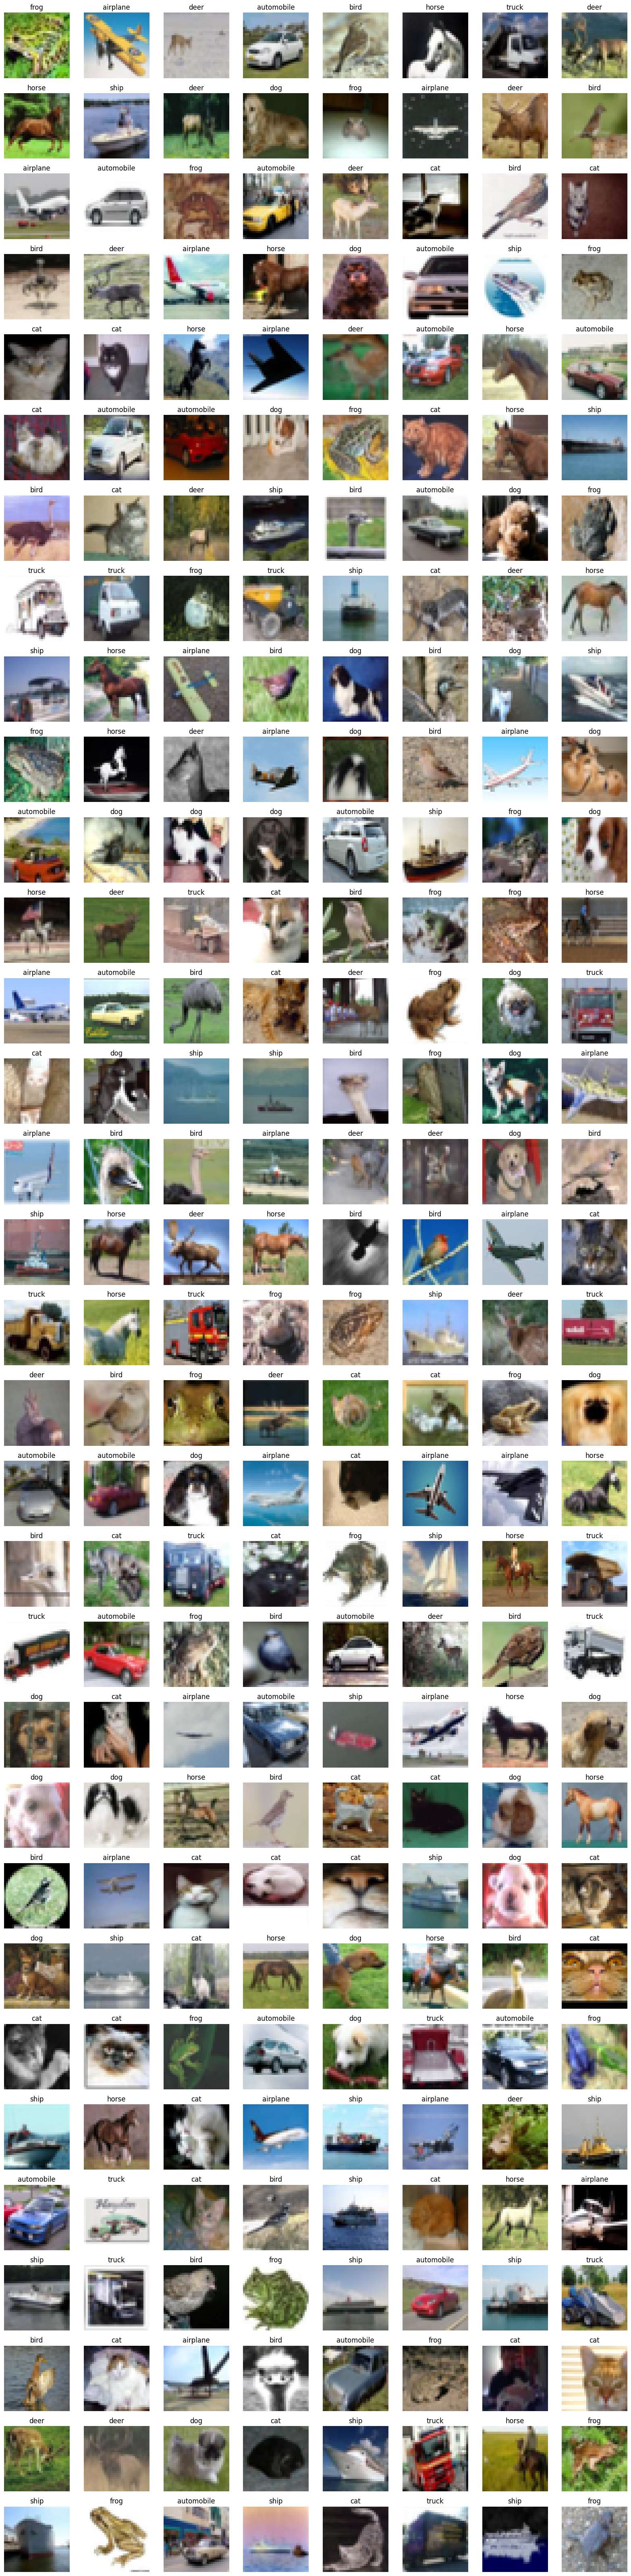

In [97]:
show_batch(train_loader)

In [98]:
num_classes = 10

## Define helper functions for training and metrics

You will need these again and again. 

In [99]:
## TODO: write a function that calculates the accuracy

def accuracy(correct, total): 
    """
    function to calculate the accuracy given the
        correct: number of correctly classified samples
        total: total number of samples
    returns the ratio
    """
    accuracy = correct / total
    
    return accuracy

In [100]:
## TODO: Define a train and validation functions here
## Hint - you can use yours from Practical 2 


def train(dataloader, optimizer, model, loss_fn, device, master_bar):
    """ method to train the model """
    model.train()
    master_bar.set_description("Training")

    train_losses = []
    correct = 0
    total = 0

    for x_batch, y_batch in dataloader: # x_batch := Bilder; y_batch := labels
        
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        # forward pass
        y_pred = model(x_batch)

        # loss
        loss = loss_fn(y_pred, y_batch)

        # backward pass
        loss.backward()

        # update parameters
        optimizer.step()

        # save batch loss
        train_losses.append(loss.item())

        # accuracy
        predicted_classes = torch.argmax(y_pred, dim = 1) # which class/label has the highest probability ?
        correct += (predicted_classes == y_batch).sum().item() # how many samples of the batch are correctly classified ?
        total += y_batch.size(0) # how big is the batch? <=> batch_size for first n-1; last batch could be smaller 

    mean_train_loss = np.mean(train_losses)
    train_accuracy = accuracy(correct, total)

    return mean_train_loss, train_accuracy

    # TODO: refine the training function from above
  # it should contain:
  # - saving of losses
  # - calculation of accuracy
  # - returning the mean loss and accuracy


def validate(dataloader, model, loss_fn, device, master_bar):
    """ method to compute the metrics on the validation set """

    model.eval()
    master_bar.set_description("Validation")

    val_losses = []
    correct = 0
    total = 0

    with torch.no_grad():
        for x_batch, y_batch in dataloader:  # x_batch := Bilder; y_batch := labels

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            # forward pass
            y_pred = model(x_batch)

            # loss
            loss = loss_fn(y_pred, y_batch)

            # save batch loss
            val_losses.append(loss.item())

            # accuracy
            predicted_classes = torch.argmax(y_pred, dim = 1)
            correct += (predicted_classes == y_batch).sum().item()
            total += y_batch.size(0)

    mean_val_loss = np.mean(val_losses)
    val_accuracy = accuracy(correct, total)

    return mean_val_loss, val_accuracy

      # TODO: write a validation function that calculates the loss and accuracy on the validation set
    # you can also combine it with the training function

In [101]:
#TODO: write a run_training function that 
# - calls the train and validate functions for each epoch
# - saves the train_losses, val_losses, train_accs, val_accs as arrays for each epoch
## Hint - you can use yours from Practical 2 
from tqdm import trange

def run_training(model, optimizer, loss_function, device, num_epochs, train_dataloader, val_dataloader):
    """ method to run the training procedure """

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    master_bar = trange(num_epochs)

    for epoch in master_bar:

        mean_train_loss, train_accuracy = train(
            train_dataloader,
            optimizer,
            model,
            loss_function,
            device,
            master_bar
        )

        mean_val_loss, val_accuracy = validate(
            val_dataloader,
            model,
            loss_function,
            device,
            master_bar
        )

        train_losses.append(mean_train_loss)
        val_losses.append(mean_val_loss)
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

        master_bar.set_postfix(
            train_loss = f"{mean_train_loss:.4f}",
            val_loss = f"{mean_val_loss:.4f}",
            train_acc = f"{train_accuracy:.4f}",
            val_acc = f"{val_accuracy:.4f}"
        )

    return train_losses, val_losses, train_accs, val_accs
    
    # TODO: write a run_training function that 
  # - calls the train and validate functions for each epoch
  # - saves the train_losses, val_losses, train_accs, val_accs as arrays for each epoch

In [102]:
# TODO: write a function to calculate and return the confusion values
def calc_confusion_values(dataloader, model, device):
    """ method to compute the confusion values on the validation set """

    model.eval()

    num_classes = len(dataloader.dataset.classes)
    confusion_values = torch.zeros(num_classes, num_classes)

    with torch.no_grad():
        for x_batch, y_batch in dataloader:  # x_batch := Bilder; y_batch := labels

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            # forward pass
            y_pred = model(x_batch)

            # prediction
            predicted_classes = torch.argmax(y_pred, dim = 1)

            # confusion values
            for true_label, predicted_label in zip(y_batch, predicted_classes):
                confusion_values[true_label, predicted_label] += 1

    return confusion_values

## Logistic Regression   

In [103]:
# TODO: define logistic regression model class and its necessary functions
# What are the dimensions of your input layer?
# TODO: flatten the input to a suitable size for the initial layer

class LogisticRegression(nn.Module):
    def __init__(self, input_shape, num_classes):
        super(LogisticRegression, self).__init__()

        self.input_dim = np.prod(input_shape)
        self.num_classes = num_classes

        self.linear = nn.Linear(self.input_dim, self.num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        out = self.linear(x)
        return out

In [104]:
## TODO : Define network, put it to the device and train mode

# Get input values from dataset
sample_image, sample_label = train_dataset[0]

input_shape = sample_image.shape # [3, 32, 32] 3 Farbkanäle, 32x32 Pixel
num_classes = len(train_dataset.classes) # 10 Klassen

# Define model
logistic_regression = LogisticRegression(input_shape, num_classes)

# Move model to device (CPU or GPU)
logistic_regression = logistic_regression.to(device)

# Set to training mode
logistic_regression.train()

LogisticRegression(
  (linear): Linear(in_features=3072, out_features=10, bias=True)
)

In [105]:
## Optimizer defined. We're going to use Adam since it's always the safe bet, and also for faster convergence. 
optimizer = torch.optim.Adam(logistic_regression.parameters(), lr = 0.001)

In [106]:
input_dim = np.prod(input_shape)

print(input_shape)
print(input_dim)

torch.Size([3, 32, 32])
3072


Each image has 3 color channels: red, green, and blue (RGB). Each channel has a size of 32 x 32 pixels. For logistic regression, we flatten the image, so every pixel value in every channel becomes one input feature. Therefore, the number of input features is 3 * 32 * 32 = 3072. For a batch of images, the input to the model has shape batch_size x 3072.

### Define loss 

Since we're dealing with multi-class classification (i.e. multiple categories), softmax is the canonical choice for the final layer activation. Softmax provides us with a distribution of values in \[0, 1\] that sum up to 1 over all categories.

We then use the cross entropy to compute the loss.

Hint: Due to numerical reasons, softmax and cross entropy are combined into one operation. Read more about it in https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html.

In [107]:
# TODO: define the loss function
loss_function = nn.CrossEntropyLoss()

In [108]:
num_epochs = 20

## TODO: run training over 20 epochs
regression_train_losses, regression_val_losses, regression_train_accs, regression_val_accs = run_training(
    model = logistic_regression,
    optimizer = optimizer,
    loss_function = loss_function,
    device = device,
    num_epochs = num_epochs,
    train_dataloader = train_loader,
    val_dataloader = test_loader
)

Validation: 100%|█| 20/20 [04:53<00:00, 14.68s/it, train_acc=0.4047, train_loss=1.7417, val_acc=0.3896, val_loss=1.7976


## Multilayer Perceptron

MLP is a network which consists of several linear fully-connected layers with non-linearities between them.

### Question:
Why are non-linearities between linear layers important?

Non-linearities are important because they allow the network to learn complex, non-linear relationships. Without them, several linear layers stacked together would still behave like one single linear layer.

In [109]:
## TODO: Make the 4 layer MLP  with the following shapes :
## input_dim -> 2048 -> 512 -> 128 -> output_dim
## Use RELu as nonlinearity
## In the forward pass do not forget to flatten the input

class MLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(MLP, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 2048),
            nn.ReLU(),

            nn.Linear(2048, 512),
            nn.ReLU(),

            nn.Linear(512, 128),
            nn.ReLU(),

            nn.Linear(128, output_dim)
        )

    def forward(self, x):
        # flatten input: (batch, 3, 32, 32) -> (batch, 3072)
        x = x.view(x.size(0), -1)
        return self.model(x)

In [110]:
## TODO: Define network, put it to device and train mode

# Get input values from dataset
input_dim = np.prod(train_dataset[0][0].shape)
output_dim = len(train_dataset.classes)

# Define model
mlp = MLP(input_dim = input_dim, output_dim = output_dim)

# Move model to device (CPU or GPU)
mlp = mlp.to(device)

# Set to training mode
mlp.train()

<bound method Module.train of MLP(
  (model): Sequential(
    (0): Linear(in_features=3072, out_features=2048, bias=True)
    (1): ReLU()
    (2): Linear(in_features=2048, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)>

In [111]:
## TODO: Define optimizer and loss functions

# optimizer
optimizer = torch.optim.Adam(mlp.parameters(), lr = 0.001)

# loss function
loss_function = nn.CrossEntropyLoss()

In [112]:
## TODO: Train the MLP over 20 epochs
mlp_train_losses, mlp_val_losses, mlp_train_accs, mlp_val_accs = run_training(
    model = mlp,
    optimizer = optimizer,
    loss_function = loss_function,
    device = device,
    num_epochs = num_epochs,
    train_dataloader = train_loader,
    val_dataloader = test_loader
)

Validation: 100%|█| 20/20 [06:07<00:00, 18.38s/it, train_acc=0.7781, train_loss=0.6196, val_acc=0.5731, val_loss=1.6097


## Add L2 regularisation

In [113]:
# TODO: Define new model, optimizer, put model to device, etc.
## 0.00005 is a good starting point for the regularization strength

# Get input values from dataset
input_dim = np.prod(train_dataset[0][0].shape)
output_dim = len(train_dataset.classes)

# Define model
mlp_l2 = MLP(input_dim = input_dim, output_dim = output_dim)

# Move model to device (CPU or GPU)
mlp_l2 = mlp_l2.to(device)

# Define optimizer WITH L2 regularization
optimizer = torch.optim.Adam(
    mlp_l2.parameters(),
    lr = 0.001,
    weight_decay = 0.00005  # L2 regularization strength
)

# Loss function
loss_function = nn.CrossEntropyLoss()

In [114]:
## TODO: Retrain new model with regularization over 20 epochs
mlp_l2_train_losses, mlp_l2_val_losses, mlp_l2_train_accs, mlp_l2_val_accs = run_training(
    model = mlp_l2,
    optimizer = optimizer,
    loss_function = loss_function,
    device = device,
    num_epochs = num_epochs,
    train_dataloader = train_loader,
    val_dataloader = test_loader
)

Validation: 100%|█| 20/20 [06:26<00:00, 19.34s/it, train_acc=0.7139, train_loss=0.7965, val_acc=0.5573, val_loss=1.4100


## LeNet5

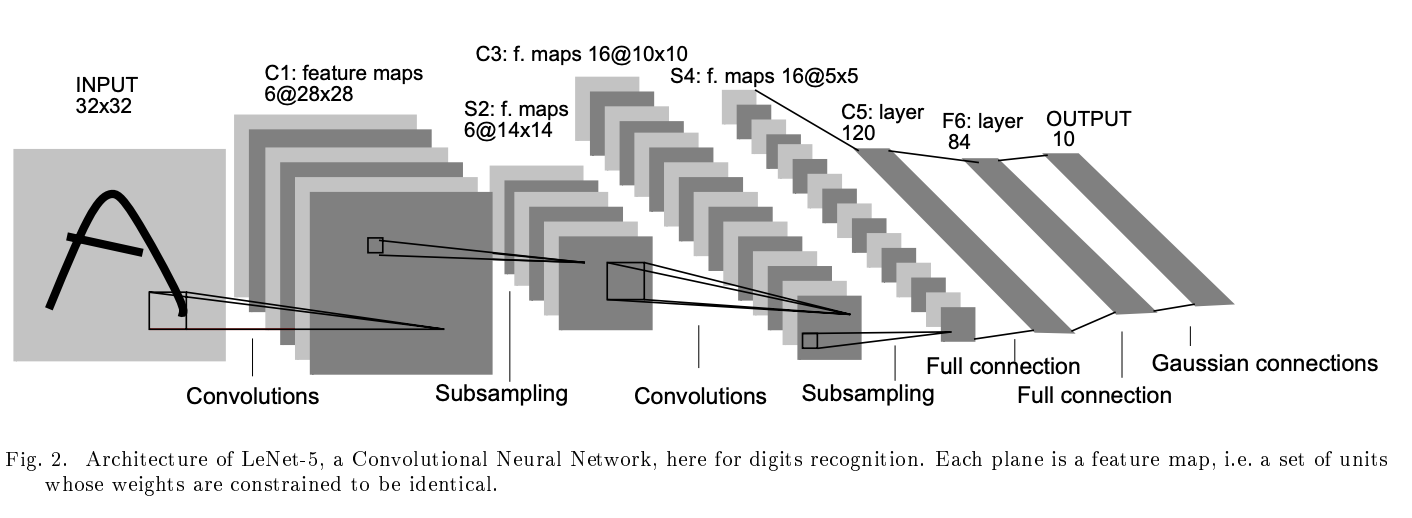

Let's implememt one of the classical convolutional network and apply it for CIFAR-10. Here is the link for the [original paper](http://vision.stanford.edu/cs598_spring07/papers/Lecun98.pdf) of LeNet5 introduced by Yann LeCun and colleagues in 1998. The original implementation of LeNet5 has Tanh as nonlinearities. In 2012, AlexNet famously set off the deep learning revolution. AlexNet is based on LeNet, with two main innovations: (1) making it deeper by adding a few extra layers and (2) replacing the tanh activation functions by ReLU to improve training. Here we'll the original LeNet5 architecture to keep the compute requirements small, but work with the more modern ReLU activation functions.

One more thing we change in the original network is the number of input channels as LeNet5 was designed for grayscale MNIST dataset, where each picture has 1 channel, while for RGB pictures we have 3 channels in the input data.


In [115]:
class LeNet5(nn.Module):

    def __init__(self, n_classes = 10, in_channels = 3):
        super(LeNet5, self).__init__()

        self.feature_extractor = nn.Sequential(
            # C1
            nn.Conv2d(in_channels = in_channels, out_channels = 6, kernel_size = 5, stride = 1),
            nn.ReLU(),

            # S2
            nn.AvgPool2d(kernel_size = 2),

            # C3
            nn.Conv2d(in_channels = 6, out_channels = 16, kernel_size = 5),
            nn.ReLU(),

            # S4
            nn.AvgPool2d(kernel_size = 2),

            # C5
            nn.Conv2d(in_channels = 16, out_channels = 120, kernel_size = 5),
            nn.ReLU()
        )

        self.classifier = nn.Sequential(
            nn.Linear(in_features = 120, out_features = 84),
            nn.ReLU(),

            nn.Linear(in_features = 84, out_features = n_classes)
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [116]:
## TODO: define network, put it to the device and train mode
# Define model
lenet = LeNet5(n_classes = 10, in_channels = 3)

# Move to device (CPU/GPU)
lenet = lenet.to(device)

# Set training mode
lenet.train()

LeNet5(
  (feature_extractor): Sequential(
    (0): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (6): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
    (7): ReLU()
  )
  (classifier): Sequential(
    (0): Linear(in_features=120, out_features=84, bias=True)
    (1): ReLU()
    (2): Linear(in_features=84, out_features=10, bias=True)
  )
)

For a quick overview of models, torchsummary.summary is quite helpful  
comment: You can also import predefined architectures from `torchvision` and run `torchsummary.summary` on them to get a quick overview

In [117]:
## TODO: run torchsummary.summary on the LeNet5 and your MLP model. What do you see?

# Get input values from dataset
sample_image, sample_label = train_dataset[0]

input_shape = sample_image.shape # [3, 32, 32] 3 Farbkanäle, 32x32 Pixel

summary(mlp, input_size = input_shape)
summary(lenet, input_size = input_shape)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                 [-1, 2048]       6,293,504
              ReLU-2                 [-1, 2048]               0
            Linear-3                  [-1, 512]       1,049,088
              ReLU-4                  [-1, 512]               0
            Linear-5                  [-1, 128]          65,664
              ReLU-6                  [-1, 128]               0
            Linear-7                   [-1, 10]           1,290
Total params: 7,409,546
Trainable params: 7,409,546
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.04
Params size (MB): 28.27
Estimated Total Size (MB): 28.32
----------------------------------------------------------------
----------------------------------------------------------------
        Layer (type)               

The summary shows that the MLP has many more parameters than LeNet5. This happens because the MLP flattens the image and uses fully connected layers, where many input features are connected to many neurons. LeNet5 uses convolutional layers, which apply small filters locally and share their weights across the image. Therefore, LeNet5 has fewer parameters and is more efficient for image data.

In [118]:
## TODO: define loss function and optimizer

# optimizer
optimizer = torch.optim.Adam(lenet.parameters(), lr = 0.001)

# loss function
loss_function = nn.CrossEntropyLoss()

In [120]:
## TODO: train with 20 epochs
num_epochs = 20

lenet_train_losses, lenet_val_losses, lenet_train_accs, lenet_val_accs = run_training(
    model = lenet,
    optimizer = optimizer,
    loss_function = loss_function,
    device = device,
    num_epochs = num_epochs,
    train_dataloader = train_loader,
    val_dataloader = test_loader
)

Validation: 100%|█| 20/20 [06:58<00:00, 20.92s/it, train_acc=0.7134, train_loss=0.8139, val_acc=0.6692, val_loss=0.9510


## Analysis 

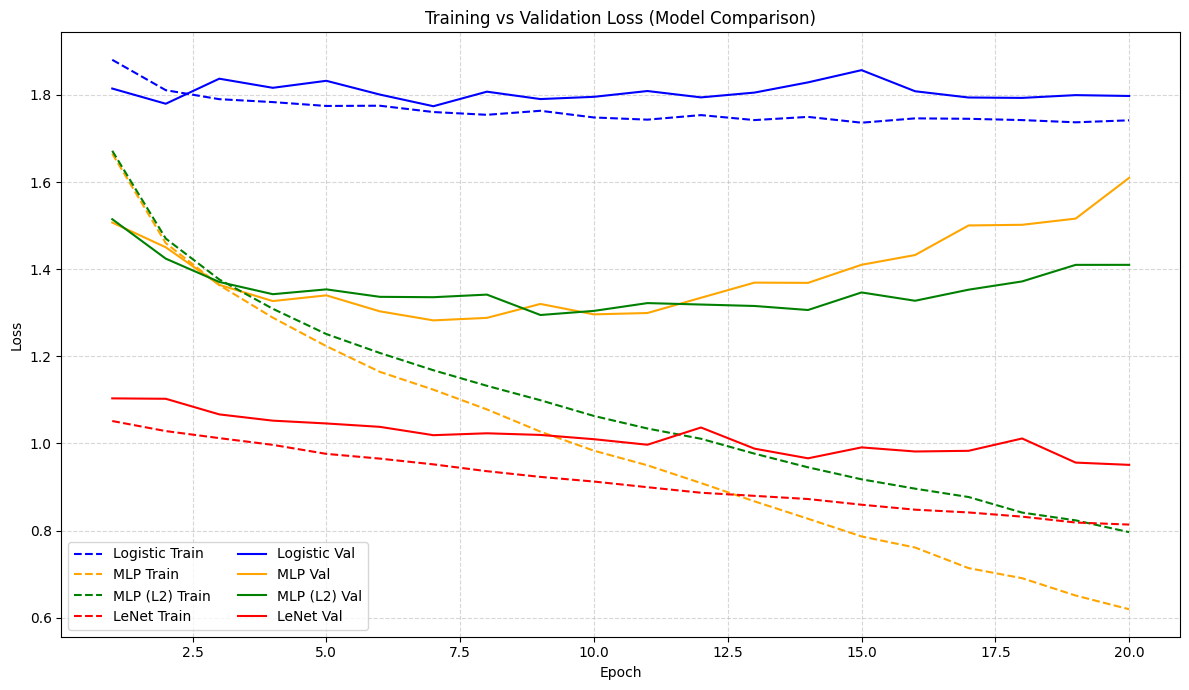

In [125]:
## TODO: Plot both train and val losses for all models.
## What do you see?

plt.figure(figsize = (12, 7))

epochs = range(1, num_epochs + 1)

colors = {
    "Logistic": "blue",
    "MLP": "orange",
    "MLP (L2)": "green",
    "LeNet": "red"
}

# Logistic Regression
logistic_train, = plt.plot(epochs, regression_train_losses, color = colors["Logistic"], linestyle = '--', label = "Logistic Train")
logistic_val, = plt.plot(epochs, regression_val_losses, color = colors["Logistic"], linestyle = '-', label = "Logistic Val")

# MLP
mlp_train, = plt.plot(epochs, mlp_train_losses, color = colors["MLP"], linestyle = '--', label = "MLP Train")
mlp_val, = plt.plot(epochs, mlp_val_losses, color = colors["MLP"], linestyle = '-', label = "MLP Val")

# MLP + L2
mlp_l2_train, = plt.plot(epochs, mlp_l2_train_losses, color = colors["MLP (L2)"], linestyle = '--', label = "MLP (L2) Train")
mlp_l2_val, = plt.plot(epochs, mlp_l2_val_losses, color = colors["MLP (L2)"], linestyle = '-', label = "MLP (L2) Val")

# LeNet
lenet_train, = plt.plot(epochs, lenet_train_losses, color = colors["LeNet"], linestyle = '--', label = "LeNet Train")
lenet_val, = plt.plot(epochs, lenet_val_losses, color = colors["LeNet"], linestyle = '-', label = "LeNet Val")

plt.title("Training vs Validation Loss (Model Comparison)")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True, linestyle = "--", alpha = 0.5)
plt.legend(
    handles = [logistic_train, mlp_train, mlp_l2_train, lenet_train, logistic_val, mlp_val, mlp_l2_val, lenet_val],
    ncol = 2
)
plt.tight_layout()

plt.show()

The training loss decreases for all models, although it decreases very slowly for logistic regression. The validation loss of logistic regression stays constant. For the MLP models, the validation loss decreases at first but then starts to increase again, which indicates overfitting. For the LeNet model, both training and validation loss are relatively low and decrease gradually over the epochs.

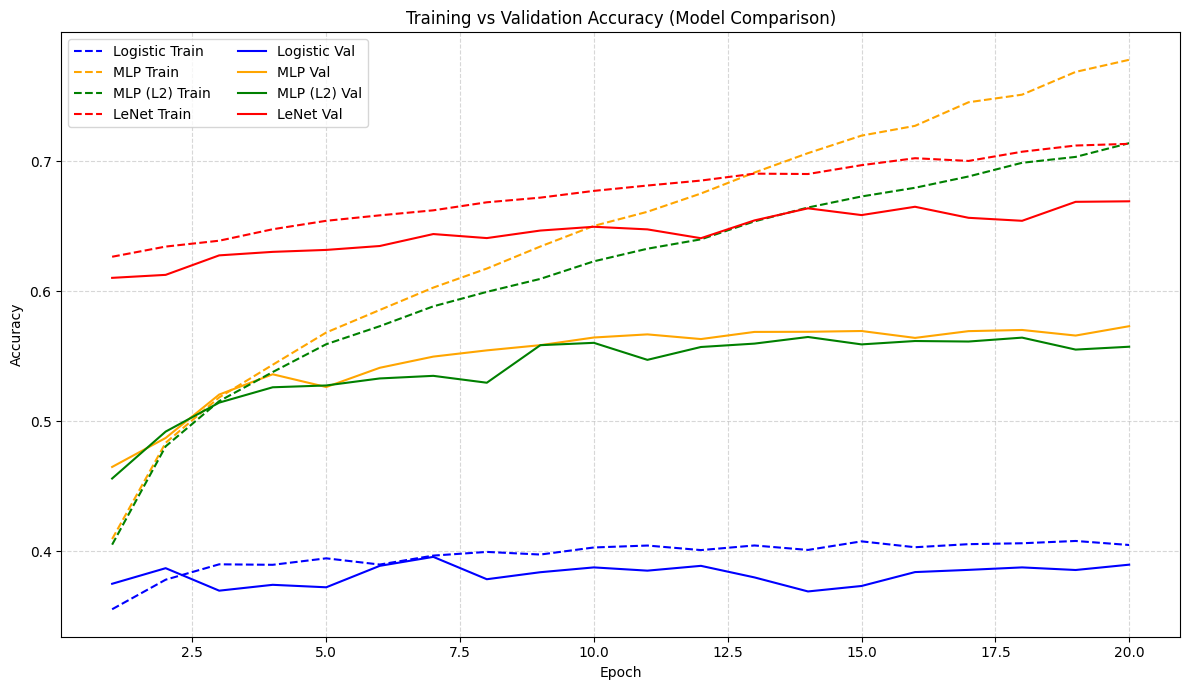

In [124]:
## TODO: Plot both train and val accuracies for all models.
## What do you see?

plt.figure(figsize = (12, 7))

epochs = range(1, num_epochs + 1)
colors = {
    "Logistic": "blue",
    "MLP": "orange",
    "MLP (L2)": "green",
    "LeNet": "red"
}

# Logistic Regression
logistic_train, = plt.plot(epochs, regression_train_accs, color = colors["Logistic"], linestyle = '--', label = "Logistic Train")
logistic_val, = plt.plot(epochs, regression_val_accs, color = colors["Logistic"], linestyle = '-', label = "Logistic Val")

# MLP
mlp_train, = plt.plot(epochs, mlp_train_accs, color = colors["MLP"], linestyle = '--', label = "MLP Train")
mlp_val, = plt.plot(epochs, mlp_val_accs, color = colors["MLP"], linestyle = '-', label = "MLP Val")

# MLP + L2
mlp_l2_train, = plt.plot(epochs, mlp_l2_train_accs, color = colors["MLP (L2)"], linestyle = '--', label = "MLP (L2) Train")
mlp_l2_val, = plt.plot(epochs, mlp_l2_val_accs, color = colors["MLP (L2)"], linestyle = '-', label = "MLP (L2) Val")

# LeNet
lenet_train, = plt.plot(epochs, lenet_train_accs, color = colors["LeNet"], linestyle = '--', label = "LeNet Train")
lenet_val, = plt.plot(epochs, lenet_val_accs, color = colors["LeNet"], linestyle = '-', label = "LeNet Val")

plt.title("Training vs Validation Accuracy (Model Comparison)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.grid(True, linestyle = "--", alpha = 0.5)
plt.legend(
    handles = [logistic_train, mlp_train, mlp_l2_train, lenet_train, logistic_val, mlp_val, mlp_l2_val, lenet_val],
    ncol = 2
)
plt.tight_layout()

plt.show()

The training accuracy increases for all models at the beginning. For logistic regression, it becomes almost constant after a few epochs, while it continues to increase for the other models. The validation accuracy of logistic regression also stays almost constant. For the MLP models, the validation accuracy increases quickly at first and then converges. For LeNet, the validation accuracy increases gradually.

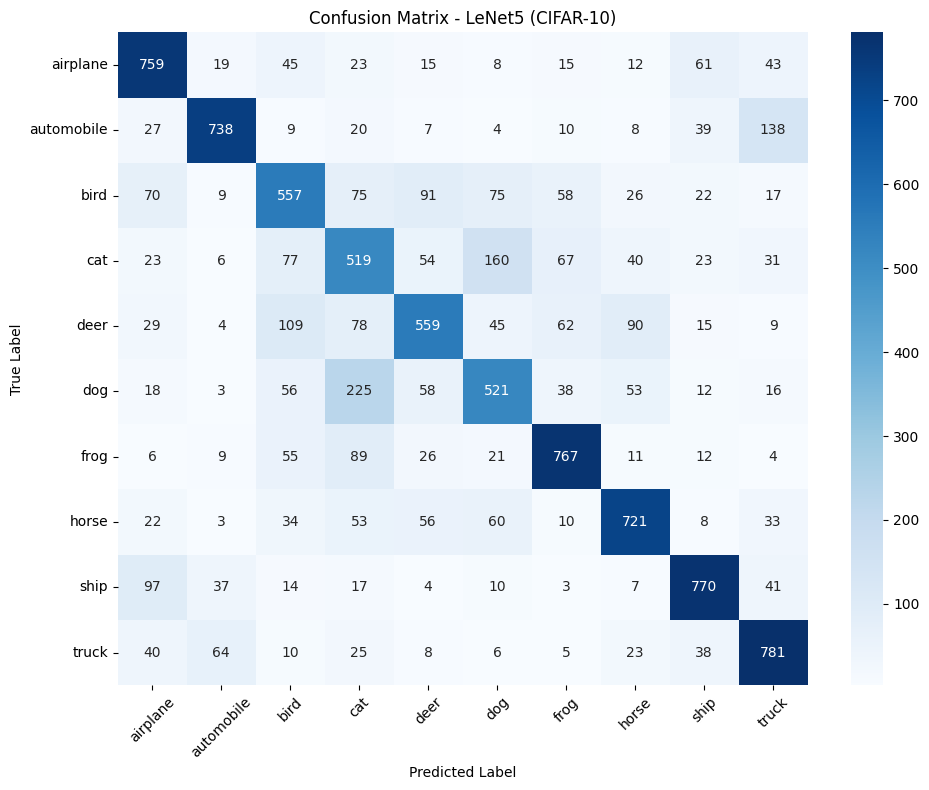

In [123]:
## TODO: Plot the confusion matrix for LeNet5
conf_matrix = calc_confusion_values(test_loader, lenet, device)

classes = test_dataset.classes

plt.figure(figsize = (10, 8))

sns.heatmap(
    conf_matrix.cpu().numpy(),
    annot = True,
    fmt = ".0f",
    cmap = "Blues",
    xticklabels = classes,
    yticklabels = classes
)

plt.title("Confusion Matrix - LeNet5 (CIFAR-10)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation = 45)
plt.yticks(rotation = 0)

plt.tight_layout()
plt.show()

## Questions
* How did regularization change the performance of the MLP? Why?
    * L2 regularization affected the performance only marginally. For both MLP models, the validation loss decreases at first and then increases again, which indicates overfitting. The validation accuracy also converges to a similar level for both models. Therefore, in this experiment, L2 regularization did not noticeably improve the generalization performance.
* Explain the confusion matrix for LeNet5. What do you see there?
    * The confusion matrix shows how often each true class was predicted correctly and which other classes were predicted instead. In our matrix, the rows represent the true classes and the columns represent the predicted classes. The values on the main diagonal show the number of correctly classified samples. The values outside the diagonal show how often classes were confused with each other.
* Explain the difference in performance between linear regression, MLP, and LeNet5.
    * Logistic regression performs worst because it is only a linear model and cannot learn complex image patterns. The MLP performs better because it uses hidden layers and non-linear activation functions, so it can learn more complex relationships between pixels. However, it still flattens the image and loses spatial structure. LeNet5 performs best because it uses convolutional layers, which preserve spatial information and learn local image features such as edges, shapes, and textures. 
* Why are convolutions better suited for pictures? Which properties of images do they exploit?
    * Convolutions are better suited for pictures because they preserve the spatial structure of images and learn local patterns. Images contain local relationships between neighboring pixels, such as edges, corners, textures, and shapes. Convolutional layers use small filters that scan over the image, so the same pattern can be detected at different positions. This makes them more efficient and better suited for image data than fully connected layers. 
* Is it important to redefine an optimizer for each different model, training? What about loss functions?
    * Yes, it is important to redefine the optimizer for each new model or training run. The optimizer is connected to the parameters of a specific model and can store internal states of the model. If we reuse the same optimizer for another model, it may still refer to the old parameters or use old optimization states. The loss function, however, usually does not need to be redefined, because it does not store model-specific parameters. For this classification task, the same CrossEntropyLoss can be used for all models. 

## Additional experiments (Optional)
* Try to replace CIFAR10 dataset with MNIST. What do you notice? Why? Try to explain the differences in terms of variance or dataset complexity
